In [6]:
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    RandomForestClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    LinearRegression,
    LogisticRegressionCV,
)
from sklearn.metrics import (
    classification_report,
    f1_score,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from matplotlib import pyplot as plt

SEED = 2026

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

In [7]:
df = pd.read_csv("data/hris_performance_train.csv")
# df.head()

In [8]:
# df.describe()

In [9]:
# Train Data

y_cont = df["job_satisfaction"]
X_cont = df.drop(columns="job_satisfaction")

y_class = df["performance_rating"]
X_class = df.drop(columns="performance_rating")

In [10]:
# Test Data

test_df = pd.read_csv("data/hris_performance_hidden_test.csv")

y_cont_test = test_df["job_satisfaction"]
X_cont_test = test_df.drop(columns="job_satisfaction")

y_class_test = test_df["performance_rating"]
X_class_test = test_df.drop(columns="performance_rating")

## Regression Task

In [11]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

In [12]:
# Train

lm = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression(fit_intercept=True, n_jobs=-1)),
    ]
)
lm.fit(X_cont, y_cont)
y_hat = lm.predict(X_cont)
mse = mean_squared_error(y_cont, y_hat)
scores = cross_val_score(lm, X_cont, y_cont, scoring="r2", cv=cv, n_jobs=-1)
print(f"MSE = {mse:.3f} and r^2 = {scores.mean():.3f}")

MSE = 109.722 and r^2 = 0.843


In [13]:
# Test

y_hat = lm.predict(X_cont_test)
mse = mean_squared_error(y_cont_test, y_hat)
r2 = r2_score(y_cont_test, y_hat)
print(f"MSE = {mse:.3f} and r^2 = {r2:.3f}")

MSE = 109.446 and r^2 = 0.844


In [36]:
# Importance using Betas

feature_importance = sorted(
    zip(X_cont.columns, np.abs(lm.named_steps.regressor.coef_)),
    key=lambda x: x[1],
    reverse=True,
)

# feature_importance

In [33]:
# Permutation Importance

result = permutation_importance(
    lm, X_cont, y_cont, n_repeats=10, scoring="r2", random_state=SEED
)

assert result.importances_mean.shape[0] == X_cont.shape[1]

pd.Series(result.importances_mean, index=X_cont.columns).sort_values(ascending=False).round(5)

commute_minutes             0.74114
remote_work_ratio           0.45139
training_hours_12mo         0.26369
last_promotion_years_ago    0.22677
engagement_percent          0.00334
engagement_score            0.00312
tenure_months               0.00243
tenure_years                0.00242
department_code             0.00002
overtime_hours_month        0.00001
absences_days_12mo          0.00000
goal_completion_rate        0.00000
team_size                   0.00000
performance_rating          0.00000
age_years                   0.00000
job_level                   0.00000
dtype: float64

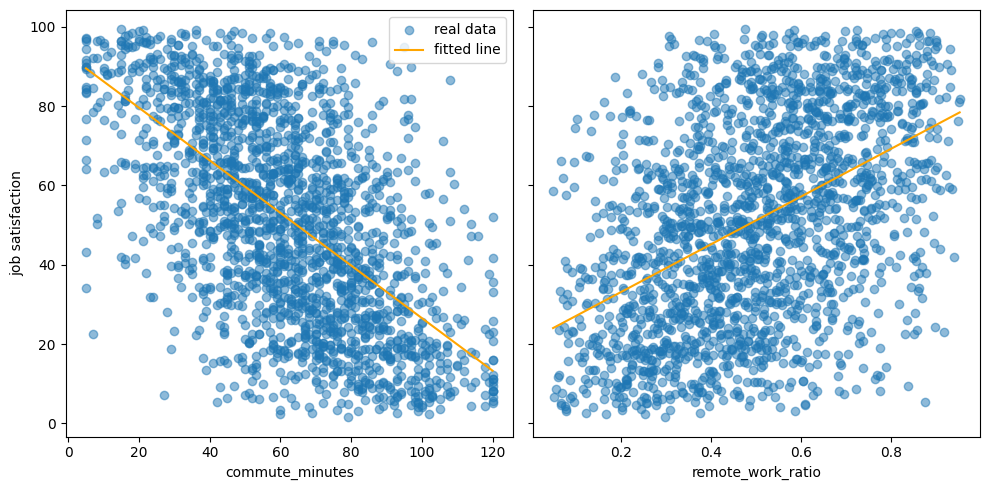

In [16]:
# Visualization

top_2 = ["commute_minutes", "remote_work_ratio"]
fig, axes = plt.subplots(ncols=2, figsize=(10, 5), sharey=True)


idx = np.random.choice(X_cont.shape[0], size=2000, replace=False)

for i, feat in enumerate(top_2):
    X_partial = X_cont.copy()
    for colname in X_partial.columns:
        if colname != feat:
            X_partial[colname] = X_partial[colname].median()
    X_partial = X_partial.iloc[idx]
    x = X_partial[feat]
    y = y_cont.iloc[idx]
    y_pred = lm.predict(X_partial)
    order = np.argsort(x)
    axes[i].scatter(x, y, alpha=0.5, label="real data")
    axes[i].plot(x.iloc[order], y_pred[order], color="orange", label="fitted line")
    axes[i].set_xlabel(feat)
axes[0].set_ylabel("job satisfaction")
axes[0].legend()
plt.tight_layout()
plt.show()

## Classification Task

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Logistic Regression

In [18]:
lr = LogisticRegressionCV(
    penalty="l2",
    Cs=10,
    fit_intercept=True,
    random_state=SEED,
    max_iter=5_000,
    solver="lbfgs",
    n_jobs=-1,
    class_weight="balanced",
    cv=cv,
    scoring="f1_weighted",
)

lr_pipeline = Pipeline([("scaler", StandardScaler()), ("classifier", lr)])

lr_pipeline.fit(X_class, y_class)
y_hat = lr_pipeline.predict(X_class)

print("Training report:")
print(f"weighted f1: {f1_score(y_class, y_hat, average='weighted'):.3f}")

Training report:
weighted f1: 0.353


In [19]:
# LR Test

y_hat = lr_pipeline.predict(X_class_test)
report = classification_report(y_class_test, y_hat, zero_division=np.nan)
print("Test report:")
print(report)

Test report:
              precision    recall  f1-score   support

           1       0.10      0.13      0.11      2032
           2       0.30      0.45      0.36      4396
           3       0.71      0.30      0.42     18457
           4       0.23      0.31      0.26      5573
           5       0.12      0.47      0.19      2042

    accuracy                           0.32     32500
   macro avg       0.29      0.33      0.27     32500
weighted avg       0.50      0.32      0.35     32500



### KNN

In [20]:
# Train
knn = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=25, n_jobs=-1)),
    ]
)

cv_scores = cross_val_score(knn, X_class, y_class, cv=cv, scoring="f1_weighted")
print(f"CV average weighted f1:\n{cv_scores.mean()}")

knn.fit(X_class, y_class)

y_hat = knn.predict(X_class)
report = classification_report(y_class, y_hat, zero_division=np.nan)
print(f"Full Training Set Report:\n{report}")

CV average weighted f1:
0.5521548992445567
Full Training Set Report:
              precision    recall  f1-score   support

           1       0.72      0.03      0.05      6095
           2       0.66      0.35      0.45     13187
           3       0.65      0.97      0.78     55370
           4       0.62      0.27      0.37     16722
           5       0.61      0.04      0.08      6126

    accuracy                           0.65     97500
   macro avg       0.65      0.33      0.35     97500
weighted avg       0.65      0.65      0.58     97500



In [21]:
# Test

y_hat = knn.predict(X_class_test)
report = classification_report(y_class_test, y_hat)
print(report)

              precision    recall  f1-score   support

           1       0.55      0.02      0.04      2032
           2       0.62      0.32      0.42      4396
           3       0.64      0.97      0.77     18457
           4       0.54      0.23      0.32      5573
           5       0.58      0.04      0.07      2042

    accuracy                           0.63     32500
   macro avg       0.59      0.31      0.33     32500
weighted avg       0.61      0.63      0.56     32500



### Decision Tree

In [22]:
# Train

dt = DecisionTreeClassifier(
    random_state=SEED, class_weight="balanced", ccp_alpha=0.000015
)

dt.fit(X_class, y_class)
y_hat = dt.predict(X_class)
print(f"Full training set f1: {f1_score(y_class, y_hat, average='weighted'):.3f}")

cv_scores = cross_val_score(dt, X_class, y_class, cv=cv, scoring="f1_weighted")
print(f"CV f1s:\n{cv_scores}")

Full training set f1: 0.886
CV f1s:
[0.59747966 0.59815283 0.59845545 0.59505192 0.59556381]


In [23]:
# Test

y_hat = dt.predict(X_class_test)
print(f"Weighted f1 score: {f1_score(y_class_test, y_hat, average='weighted'):.3f}")

Weighted f1 score: 0.600


### Random Forests

In [24]:
# Train
# A callable provided for oob scoring.
def f1_scoring(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted")


rf = RandomForestClassifier(
    n_estimators=464,
    random_state=SEED,
    class_weight="balanced",
    max_depth=17,
    max_features=0.5,
    bootstrap=True,
    oob_score=f1_scoring,
    n_jobs=-1,
)
rf.fit(X_class, y_class)
y_hat = rf.predict(X_class)
# report = classification_report(y_class, y_hat, zero_division=np.nan)
# print(f"Full Training Set Report:\n{report}")
print(f"OOB weighted f1 score: {rf.oob_score_:.3f}")

OOB weighted f1 score: 0.728


In [25]:
# Test

y_hat = rf.predict(X_class_test)
# report = classification_report(y_class_test, y_hat, zero_division=np.nan)
# print(report)
print(f"Weighted f1 score: {f1_score(y_class_test, y_hat, average='weighted'):.3f}")

Weighted f1 score: 0.732


In [27]:
# Feature Importance

pd.Series(rf.feature_importances_, index=X_class.columns).sort_values(ascending=False)

absences_days_12mo          0.152365
goal_completion_rate        0.138356
tenure_years                0.104739
job_level                   0.090316
engagement_score            0.081553
engagement_percent          0.074062
tenure_months               0.058982
remote_work_ratio           0.041911
job_satisfaction            0.039289
commute_minutes             0.037705
age_years                   0.037220
training_hours_12mo         0.035353
team_size                   0.032134
overtime_hours_month        0.031778
department_code             0.024932
last_promotion_years_ago    0.019304
dtype: float64